# Import Libraries


In [55]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


## 1. Load and Flatten Raw JSON Dataset

The dataset is stored as a **nested JSON document**, where each record represents a credit application containing:  

- **Applicant information**
- **Financial indicators**
- **Spending behaviour**
- **The final lending decision**

To prepare the data for analysis, the nested structure is **flattened** using `pandas.json_normalize()`, converting nested attributes into columns so that each row corresponds to a credit application and each column represents a specific attribute.


In [56]:
file_path = "../data/raw/raw_credit_applications.json"

with open(file_path, "r") as f:
    raw = json.load(f)

df_raw = pd.json_normalize(raw, sep=".")
print("First 5 rows of the flattened DataFrame:")
print(df_raw.head())


First 5 rows of the flattened DataFrame:
       _id                                  spending_behavior  \
0  app_200  [{'category': 'Shopping', 'amount': 480}, {'ca...   
1  app_037  [{'category': 'Rent', 'amount': 608}, {'catego...   
2  app_215              [{'category': 'Rent', 'amount': 109}]   
3  app_024           [{'category': 'Fitness', 'amount': 575}]   
4  app_184     [{'category': 'Entertainment', 'amount': 463}]   

   processing_timestamp applicant_info.full_name        applicant_info.email  \
0  2024-01-15T00:00:00Z              Jerry Smith   jerry.smith17@hotmail.com   
1                   NaN           Brandon Walker   brandon.walker2@yahoo.com   
2                   NaN              Scott Moore      scott.moore94@mail.com   
3                   NaN               Thomas Lee  thomas.lee6@protonmail.com   
4  2024-01-15T00:00:00Z          Brian Rodriguez   brian.rodriguez86@aol.com   

  applicant_info.ssn applicant_info.ip_address applicant_info.gender  \
0        596-64

## 2. Dataset Overview

Before performing data quality checks, we inspect the structure of the dataset to identify number of variables, their data types, and detect potential isssues such as missing values, inconsistent formats, or type mismatches.

In [57]:
print("DataFrame Info:")
df_raw.info()

print("\nColumn names:")
for col in df_raw.columns:
    print(f"- {col}")


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    str    
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     str    
 3   applicant_info.full_name          502 non-null    str    
 4   applicant_info.email              502 non-null    str    
 5   applicant_info.ssn                497 non-null    str    
 6   applicant_info.ip_address         497 non-null    str    
 7   applicant_info.gender             501 non-null    str    
 8   applicant_info.date_of_birth      501 non-null    str    
 9   applicant_info.zip_code           501 non-null    str    
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  fin

### Initial Observations

From the dataset inspection, several important observations emerge:

• The dataset contains **502 records and 21 variables**. Each record represents a credit application entry, although further validation is required to determine whether all records correspond to unique applications or if duplicate entries are present.

• Some fields contain **missing values**, particularly:
  - `processing_timestamp`
  - `loan_purpose`
  - `decision.interest_rate`
  - `decision.approved_amount`
  - `financials.annual_salary`
  - `notes`

• The column `financials.annual_income` is stored as **object instead of a numeric type**, which may indicate inconsistent formatting or mixed data types.

• Several attributes appear **optional or sparsely populated** (e.g., `loan_purpose`, `notes`), suggesting possible schema inconsistencies or incomplete data collection.

• The field `spending_behavior` remains an **object containing nested structures**, meaning additional transformation may be required for detailed analysis.

These findings confirm the presence of **data quality issues that must be addressed before performing bias analysis** and **governance evaluation.**

## 3. Data Quality Audit
### 3.1 Completeness

#### 3.1.1 Missing Values (NaN)
Missing information reduces the reliability of the data and affects downstream analyses such as bias detection or model evaluation.

The presence of **null values across all variables** is examined to identify and quantify attributes with incomplete records.


In [58]:
missing_count = df_raw.isnull().sum()
missing_percentage = (missing_count / len(df_raw)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage (%)": missing_percentage.round(2)
}).sort_values("Percentage (%)", ascending=False)

missing_table.head(21) 


,Missing Values,Percentage (%)
notes,500,99.60
financials.annual_salary,497,99.00
loan_purpose,452,90.04
processing_timestamp,440,87.65
decision.rejection_reason,292,58.17
decision.approved_amount,210,41.83
decision.interest_rate,210,41.83
financials.annual_income,5,1.00
applicant_info.ip_address,5,1.00
applicant_info.ssn,5,1.00


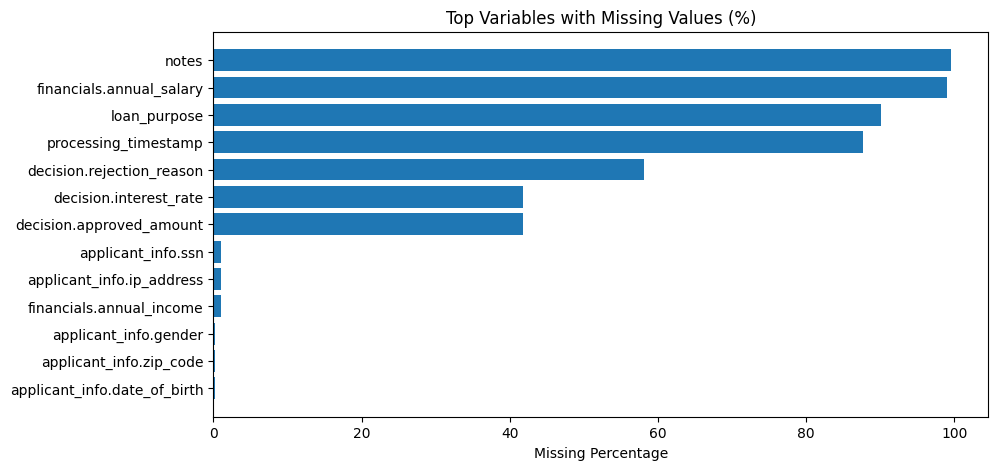

In [59]:
# Display the top 15 variables with the highest missing value percentages
top = missing_table[missing_table["Percentage (%)"] > 0].head(15).sort_values("Percentage (%)")
plt.figure(figsize=(10,5))
plt.barh(top.index, top["Percentage (%)"])
plt.title("Top Variables with Missing Values (%)")
plt.xlabel("Missing Percentage")
plt.show()


#### Findings:

The analysis reveals substantial variation in data completeness across variables.

- Several attributes, such as `notes`, `financials.annual_salary`, `loan_purpose`, and `processing_timestamp`, exhibit very high missingness levels, suggesting that they may be optional or inconsistently captured during data collection.

- Decision-related attributes (`decision.interest_rate` and `decision.approved_amount`) are missing for a subset of records.

- In contrast, financial indicators such as `financials.debt_to_income` and `financials.credit_history_months` show no missing values, indicating that these variables are consistently recorded and likely required for the lending decision process.

#### Structural Missingness vs. Random Missingness

Not all missing values necessarily indicate data quality problems. In some cases, missing values occur by design because certain variables are only relevant under specific conditions.

- The variables `decision.interest_rate` and `decision.approved_amount` are populated only when a loan application is approved.Missing values in these fields therefore represent **structural missingness**, consistent with the decision logic of the lending process.

- Missing values observed in the remaining attributes such as `processing_timestamp`, `loan_purpose`, or certain applicant information fields  represent **non-structural missingness**, which may indicate incomplete data collection or inconsistencies in the data ingestion process.

In [60]:
df_raw.groupby("decision.loan_approved")[["decision.interest_rate","decision.approved_amount"]].count()


,decision.interest_rate,decision.approved_amount
decision.loan_approved,,
False,0,0
True,292,292


#### 3.1.2 Empty String Values
Missing information may also appear in the form of **empty strings ("")**. Unlike null values, empty strings are not automatically detected as missing by most data analysis tools and may therefore obscure incomplete data.

The dataset is therefore examined to identify variables where empty strings are used instead of proper null values.

In [61]:
empty_counts = (df_raw == "").sum()
empty_string_table=pd.DataFrame({"Empty String Count": empty_counts[empty_counts > 0]}).sort_values("Empty String Count",ascending=False)
empty_string_table.head()


,Empty String Count
applicant_info.email,7
applicant_info.date_of_birth,4
applicant_info.gender,2
applicant_info.zip_code,1


#### Findings:

This analysis shows that in certain variables missing information is enconded as strings rather than proper null entries, indicating inconsistencies in how missing data is represented and may hinder accurate detection of incomplete records during analysis.

To ensure consistent handling of missing values, empty string entries are standardised by converting them to null values (`NaN`). 

In [62]:
# First Remediation Step: Convert empty string values to null values
df_raw = df_raw.replace("", np.nan)
remaining_empty_strings = (df_raw == "").sum().sum() # verify if empty string entries were successfully converted to NaN
print("Remaining empty string values:", remaining_empty_strings) 


Remaining empty string values: 0


Following this first remediation step, missing values in the dataset are represented consistently using NaN values, enabling more reliable completeness analysis.